 Dengue Case Forecasting using Time Series

This project analyzes dengue case trends from 2021–2025 and uses 
time-series forecasting models to predict future cases.

Goals:
• Understand dengue trends
• Build a forecasting model
• Predict future dengue cases

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

from statsmodels.tsa.seasonal import seasonal_decompose

## load Dataset

In [32]:
df = pd.read_csv("../data/dengue.csv")
df.head()

,S. No.,Month,2021 - Suspected,2021 - Affected,2021 - Death,2022 - Suspected,2022 - Affected,2022 - Death,2023 - Suspected,2023 - Affected,2023 - Death,2024 - Suspected,2024 - Affected,2024 - Death,2025 - Suspected,2025 - Affected,2025 - Death
0,1,January,53,12,0,59,15,0,149,17,0,142,25,0,317.0,36.0,0.0
1,2,February,47,12,0,26,11,0,142,28,0,135,22,0,214.0,32.0,0.0
2,3,March,35,11,0,14,2,0,111,28,0,72,11,0,297.0,29.0,0.0
3,4,April,5,2,0,22,6,0,57,8,0,75,13,0,287.0,34.0,0.0
4,5,May,9,4,0,15,5,0,80,9,0,107,33,0,177.0,37.0,0.0


## Dataset Information

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S. No.            13 non-null     int64  
 1   Month             13 non-null     object 
 2   2021 - Suspected  13 non-null     int64  
 3   2021 - Affected   13 non-null     int64  
 4   2021 - Death      13 non-null     int64  
 5   2022 - Suspected  13 non-null     int64  
 6   2022 - Affected   13 non-null     int64  
 7   2022 - Death      13 non-null     int64  
 8   2023 - Suspected  13 non-null     int64  
 9   2023 - Affected   13 non-null     int64  
 10  2023 - Death      13 non-null     int64  
 11  2024 - Suspected  13 non-null     int64  
 12  2024 - Affected   13 non-null     int64  
 13  2024 - Death      13 non-null     int64  
 14  2025 - Suspected  10 non-null     float64
 15  2025 - Affected   10 non-null     float64
 16  2025 - Death      10 non-null     float64
dtyp

## Satatical Summary

In [34]:
df.describe()

,S. No.,2021 - Suspected,2021 - Affected,2021 - Death,2022 - Suspected,2022 - Affected,2022 - Death,2023 - Suspected,2023 - Affected,2023 - Death,2024 - Suspected,2024 - Affected,2024 - Death,2025 - Suspected,2025 - Affected,2025 - Death
count,13.00000,13.000000,13.000000,13.0,13.000000,13.000000,13.0,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,10.000000,10.000000,10.0
mean,7.00000,840.615385,182.153846,0.0,441.692308,104.153846,0.0,964.000000,199.076923,0.461538,989.076923,180.307692,0.153846,683.400000,86.700000,0.0
std,3.89444,1429.890062,317.954883,0.0,777.862497,182.788970,0.0,1670.592959,349.085343,0.967418,1729.178054,312.275355,0.375534,977.065129,120.491632,0.0
min,1.00000,5.000000,2.000000,0.0,14.000000,2.000000,0.0,57.000000,8.000000,0.000000,72.000000,11.000000,0.000000,177.000000,25.000000,0.0
25%,4.00000,47.000000,12.000000,0.0,26.000000,11.000000,0.0,139.000000,26.000000,0.000000,107.000000,23.000000,0.000000,289.500000,32.500000,0.0
50%,7.00000,307.000000,92.000000,0.0,121.000000,23.000000,0.0,348.000000,28.000000,0.000000,321.000000,70.000000,0.000000,331.500000,36.500000,0.0
75%,10.00000,840.000000,185.000000,0.0,509.000000,139.000000,0.0,1010.000000,209.000000,0.000000,1153.000000,198.000000,0.000000,498.250000,66.250000,0.0
max,13.00000,5284.000000,1184.000000,0.0,2871.000000,677.000000,0.0,6266.000000,1294.000000,3.000000,6429.000000,1172.000000,1.000000,3417.000000,419.000000,0.0


## Missing Values check

In [35]:
df.isnull().sum()

S. No.              0
Month               0
2021 - Suspected    0
2021 - Affected     0
2021 - Death        0
2022 - Suspected    0
2022 - Affected     0
2022 - Death        0
2023 - Suspected    0
2023 - Affected     0
2023 - Death        0
2024 - Suspected    0
2024 - Affected     0
2024 - Death        0
2025 - Suspected    3
2025 - Affected     3
2025 - Death        3
dtype: int64

## Handle Missing Values

In [36]:
df = df.fillna(0)
df.isnull().sum()

S. No.              0
Month               0
2021 - Suspected    0
2021 - Affected     0
2021 - Death        0
2022 - Suspected    0
2022 - Affected     0
2022 - Death        0
2023 - Suspected    0
2023 - Affected     0
2023 - Death        0
2024 - Suspected    0
2024 - Affected     0
2024 - Death        0
2025 - Suspected    0
2025 - Affected     0
2025 - Death        0
dtype: int64

## Data Transformation

In [37]:
years = ["2021","2022","2023","2024","2025"]

data_list = []

for year in years:
    temp = pd.DataFrame({
        "Year": year,
        "Month": df["Month"],
        "Affected": df[f"{year} - Affected"]
    })
    data_list.append(temp)

ts_df = pd.concat(data_list)
    Year	Month	Affected
0	2021	January	12.0
1	2021	February	12.0
2	2021	March	11.0
3	2021	April	2.0
4	2021	May	4.0

ts_df.head()

IndentationError: unexpected indent (2271934196.py, line 14)

In [ ]:
ts_df = ts_df[ts_df["Month"] != "Total"]

## Create Time Series Index

In [ ]:
ts_df["Date"] = pd.to_datetime(
    ts_df["Month"] + " " + ts_df["Year"].astype(str),
    format="%B %Y"
)

ts_df = ts_df.sort_values("Date")

ts_df.head()

C:\Users\bhaga\AppData\Local\Temp\ipykernel_26852\1359267419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_df["Date"] = pd.to_datetime(


,Year,Month,Affected,Date
0,2021,January,12.0,2021-01-01
1,2021,February,12.0,2021-02-01
2,2021,March,11.0,2021-03-01
3,2021,April,2.0,2021-04-01
4,2021,May,4.0,2021-05-01


In [ ]:
ts_df.set_index("Date", inplace=True)

In [ ]:
ts_df.head()

,Year,Month,Affected
Date,,,
2021-01-01,2021,January,12.0
2021-02-01,2021,February,12.0
2021-03-01,2021,March,11.0
2021-04-01,2021,April,2.0
2021-05-01,2021,May,4.0


## Visualization

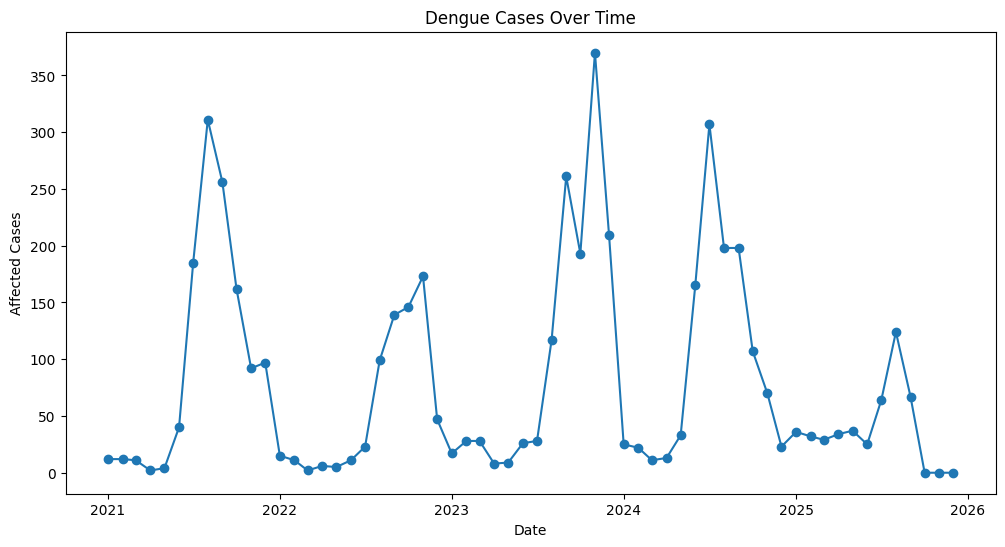

In [48]:
plt.figure(figsize=(12,6))

plt.plot(ts_df["Affected"], marker="o")

plt.title("Dengue Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Affected Cases")

plt.savefig("../trend_graph.png")
plt.show()

## Seasonal Decomposition


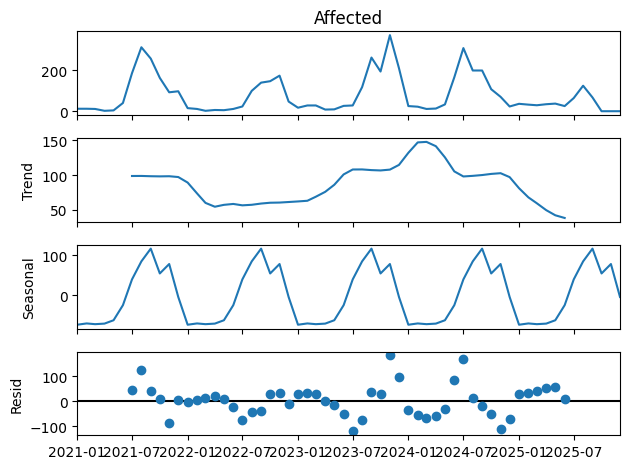

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_df["Affected"], model="additive", period=12)

decomposition.plot()
plt.show()

## Dengue Forecast Model

In [42]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

In [43]:
model_ses = SimpleExpSmoothing(ts_df["Affected"]).fit()

forecast_ses = model_ses.forecast(12)

forecast_ses

C:\Users\bhaga\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    2.216844e-22
2026-02-01    2.216844e-22
2026-03-01    2.216844e-22
2026-04-01    2.216844e-22
2026-05-01    2.216844e-22
2026-06-01    2.216844e-22
2026-07-01    2.216844e-22
2026-08-01    2.216844e-22
2026-09-01    2.216844e-22
2026-10-01    2.216844e-22
2026-11-01    2.216844e-22
2026-12-01    2.216844e-22
Freq: MS, dtype: float64

In [44]:
model_holt = Holt(ts_df["Affected"]).fit()

forecast_holt = model_holt.forecast(12)

forecast_holt

C:\Users\bhaga\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    2.216844e-22
2026-02-01    2.216844e-22
2026-03-01    2.216844e-22
2026-04-01    2.216844e-22
2026-05-01    2.216844e-22
2026-06-01    2.216844e-22
2026-07-01    2.216844e-22
2026-08-01    2.216844e-22
2026-09-01    2.216844e-22
2026-10-01    2.216844e-22
2026-11-01    2.216844e-22
2026-12-01    2.216844e-22
Freq: MS, dtype: float64

In [45]:
model_hw = ExponentialSmoothing(
    ts_df["Affected"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

forecast_hw = model_hw.forecast(12)

forecast_hw

C:\Users\bhaga\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01   -71.573822
2026-02-01   -71.506789
2026-03-01   -76.281033
2026-04-01   -79.864609
2026-05-01   -74.881887
2026-06-01   -39.132323
2026-07-01    28.816614
2026-08-01    77.150675
2026-09-01    91.535469
2026-10-01    28.929187
2026-11-01    48.376367
2026-12-01   -17.355262
Freq: MS, dtype: float64

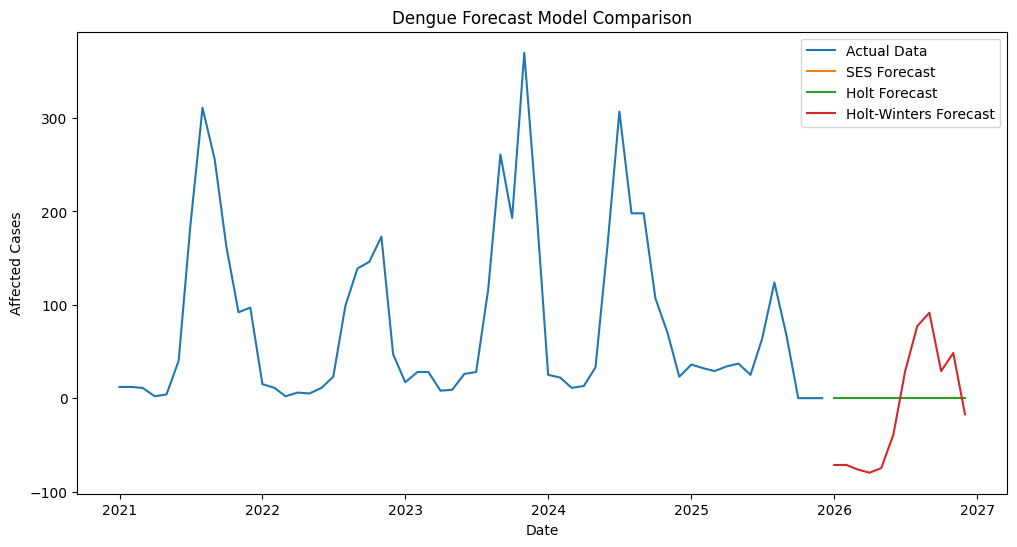

In [49]:
plt.figure(figsize=(12,6))

plt.plot(ts_df["Affected"], label="Actual Data")

plt.plot(forecast_ses, label="SES Forecast")
plt.plot(forecast_holt, label="Holt Forecast")
plt.plot(forecast_hw, label="Holt-Winters Forecast")

plt.title("Dengue Forecast Model Comparison")
plt.xlabel("Date")
plt.ylabel("Affected Cases")

plt.legend()

plt.savefig("../forecast_comparison.png")   # ADD THIS LINE

plt.show()

### Model Comparison

Three models were tested:

1. Simple Exponential Smoothing
2. Holt Trend Model
3. Holt-Winters Seasonal Model

The Holt-Winters model captures both trend and seasonal patterns and performs best for dengue case forecasting.

In [47]:
import pickle

with open("../models/dengue_forecast_model.pkl", "wb") as f:
    pickle.dump(model_hw, f)